In [1]:
from enum import Enum
from abc import ABC, abstractmethod
from dataclasses import dataclass
from datetime import datetime
from matplotlib import pyplot as plt
import pandas as pd
import re
import json

In [2]:
TRANSACTIONS_CSV = "data/transactions_dirty.csv"
TRANSACTIONS_JSON = "data/transactions_dirty.json"

## Задание 1.
Реализуйте базовый класс Account, который моделирует поведение
банковского счёта. Этот класс должен не только выполнять базовые
операции, но и вести детальный учёт всех действий, а также предоставлять аналитику по истории операций.

### Этап 1. Реализация базового класса Account
Класс должен быть инициализирован с параметрами:
- account_holder (str) — имя владельца счёта;
- balance (float, по умолчанию 0) — начальный баланс счёта, не может
быть отрицательным.
Атрибуты:
- _account_counter — приватный атрибут для хранения количества
созданных счетов. Отсчет начинается с 1000;
- holder — хранит имя владельца;
- account_number — хранит номер счёта;
- _balance — приватный атрибут для хранения текущего баланса;
- operations_history — список или другая структура для хранения
истории операций.

*Важно*: каждая операция должна храниться не просто как число, а как
структурированная информация, например, словарь, кортеж или класс.
Минимальный набор данных для операции: тип операции ('deposit' или
'withdraw'), сумма, дата и время операции, текущий баланс после операции, статус ('success' или 'fail').


### Этап 2. Реализация методов
1. __init__(self, account_holder, balance=0) — конструктор. Обратите
внимание, что в конструкторе должен автоматически формироваться
номер счёта в формате ‘ACC-XXXX’, где XXXX — порядковый номер
счёта;
2. deposit(self, amount) — метод для пополнения счёта:
- принимает сумму (должна быть положительной), попытка
положить отрицательную сумму, должна вызывать исключение;
- в случае успеха обновляет баланс и добавляет запись в историю
операций.
3. withdraw(self, amount) — метод для снятия средств:
- принимает сумму (должна быть положительной);
- проверяет, достаточно ли средств на счёте, если нет — операция
не проходит, но ее попытка с статусом 'fail' все равно фиксируется
в истории;
- в случае успеха обновляет баланс и добавляет запись в историю.
4. get_balance(self) — метод, который возвращает текущий баланс.
5. get_history(self) — метод, который возвращает историю операций

*Важно*: продумайте, в каком формате его вернуть. Для работы с датой и
временем используйте модуль datetime. Получить текущее время можно с
помощью datetime.now()

### Этап 3. Визуализация истории операций. Дополнительное задание для
претендующих на оценку 8 и выше баллов (выполняется по желанию).
1. Создайте метод plot_history(self), который использует библиотеку
Pandas для создания датафрейма из истории операций.
2. Продумайте, с помощью какой библиотеки можно отобразить
изменение баланса с течением времени. Постройте простой
линейный график, где по оси X будет время операции, а по оси Y —
баланс после каждой операции. График должен иметь заголовок,
подписи осей


## Задание 2.
### Этап 4. Реализация наследования
1. Реализуйте два класса CheckingAccount (расчётный счёт) и
SavingsAccount (сберегательный счёт), которые отражают абстракцию
базового поведения банковских аккаунтов:
 наследуются от базового класса Account;
 хранят атрибут класса account_type.
2. Класс SavingsAccount (сберегательный счёт) дополнительно должен
реализовывать метод расчёта процентов на остаток
apply_interest(self, rate) (например, 7% на остаток).
3. Класс SavingsAccount (сберегательный счёт) позволяет снимать
деньги только до определенного порога баланса: нельзя снять
больше 50% от баланса. Переопределите метод снятия со счёта
4. Реализуйте валидацию на отрицательные суммы и корректность
имени владельца:
- имя владельца счёта должно быть в формате «Имя Фамилия» с
заглавных букв, кириллицей или латиницей, иначе — должно
вызываться исключение;
- попытка положить отрицательную сумму должна вызывать
исключение.
5. Реализуйте метод для анализа истории транзакций по размеру и дате:
- метод должен выводить последние n крупных операций


## Задание 3. Дополнительное задание для претендущих на оценку 9-10 баллов (выполняется по желанию).
Перед началом работы загрузите из личного кабинете файлы, на которых
можно проверить код с «грязными» данными: transactions_dirty.csv и
transactions_dirty.json.
Реализуйте для классов аккаунтов CheckingAccount (расчётный счёт) и
SavingsAccount (сберегательный счёт) два метода:
- Метод загрузки истории в аккаунт из файла с транзакциями (файл
транзакций общий для всех аккаунтов, необходимо учесть
фильтрацию загружаемых значений).
- Метод clean_history(), который ищет ошибки в данных перед записью
транзакций в историю (опечатки, отрицательные суммы, неверные
даты). Обратите внимание, что для SavingsAccount (сберегательный
счёт) доступно три типа операции (deposit, withdraw и interest), в то
время как для CheckingAccount (расчётный счёт) доступны только два
типа операции (deposit, withdraw). Все данные с ошибками считаем
невалидными и не записываем в историю операций.
- После загрузки истории операций в аккаунт, баланс счёта должен
обновиться


In [ ]:
class OperationType(Enum):
    """Enumeration of possible operation types for an account."""
    DEPOSIT = "deposit"   # Adding funds to the account
    WITHDRAW = "withdraw" # Withdrawing funds from the account
    INTEREST = "interest" # Interest accrual (only for savings accounts)


class OperationStatus(Enum):
    """Enumeration of possible outcomes of an operation."""
    SUCCESS = "success"   # Operation completed successfully
    FAIL = "fail"         # Operation failed (e.g., insufficient funds)


class AccountType(Enum):
    """Enumeration of supported account types."""
    CHECKING_ACCOUNT = "checking"  # Regular checking account (no interest)
    SAVINGS_ACCOUNT = "savings"    # Savings account (supports interest accrual)


@dataclass
class Operation:
    """
    Represents a single account operation with full audit information.

    Attributes:
        operation_type (OperationType): The type of the operation (deposit, withdraw, interest).
        operation_status (OperationStatus): The result of the operation (success/fail).
        timestamp (datetime): The date and time when the operation occurred.
        amount (float): The amount of money involved in the operation.
        balance_after (float): The account balance after the operation was applied.
    """
    operation_type: OperationType
    operation_status: OperationStatus
    timestamp: datetime
    amount: float
    balance_after: float


In [ ]:
class Account(ABC):
    account_number: str
    holder: str
    operations_history: list[Operation]
    _account_counter: int = 1000
    _balance: float

    
    def __init__(self, account_holder: str, balance: float = 0):
        self._validate_name(account_holder)
        self._validate_balance(balance)
        
        self.holder = account_holder
        self._balance = balance
        self.account_number = f'ACC-{Account._account_counter:06d}'
        self.operations_history = []
        Account._account_counter += 1

    
    def deposit(self, amount: float):
        self._validate_amount(amount)
        
        self._balance += amount
        operation = Operation(
            operation_type=OperationType.DEPOSIT,
            operation_status=OperationStatus.SUCCESS,
            timestamp=datetime.now(),
            amount=amount,
            balance_after=self._balance
        )
        self.operations_history.append(operation)

    
    def withdraw(self, amount: float):
        self._validate_amount(amount)

        if self._balance < amount:
            operation_status = OperationStatus.FAIL
        else:
            operation_status = OperationStatus.SUCCESS
            self._balance -= amount
        
        operation = Operation(
            operation_type=OperationType.WITHDRAW,
            operation_status=operation_status,
            timestamp=datetime.now(),
            amount=amount,
            balance_after=self._balance
        )
        self.operations_history.append(operation)


    def get_balance(self) -> float:
        return self._balance
    

    def get_history(self) -> pd.DataFrame:
        df = pd.DataFrame([{
            "account_number": self.account_number,
            "account_type": self._get_account_type().value,
            "date": op.timestamp,
            "operation": op.operation_type.value,
            "amount": op.amount,
            "balance_after": op.balance_after,
            "status": op.operation_status.value
        } for op in self.operations_history])
        
        return pd.DataFrame(df)


    def clean_history(self, data: dict[str, any]) -> Operation | None:
        try:
            account_number = self._read_account_number(data)
            if not self._is_same_account_number(account_number):
                return None
            
            account_type = self._read_account_type(data)
            if not self._is_same_account_type(account_type):
                return None
            
            operation_type = self._read_operation_type(data)
            if not self._is_valid_operation_type(operation_type):
                return None

            operation = Operation(
                operation_type=operation_type,
                operation_status=self._read_operation_status(data),
                timestamp=self._read_timestamp(data),
                amount=self._read_amount(data),
                balance_after=self._read_balance_after(data)
            )

            return operation
        except ValueError as ex:
            print(ex)
            return None


    def from_json(self, path: str):
        with open(path, 'r', encoding='utf-8') as f:
            transactions = json.load(f)
        self._load_operations(transactions)


    def from_csv(self, path: str):
        df = pd.read_csv(path)
        operations = df.to_dict(orient="records")
        self._load_operations(operations)
    

    def plot_histry(self):
        history = self.get_history()

        plt.figure(figsize=(8, 4))
        plt.plot(history["date"], history["balance_after"], marker="o", linestyle="-")
        plt.title(f"Изменение баланса для счета {self.account_number}")
        plt.xlabel("Дата операции")
        plt.ylabel("Баланс после операции")
        plt.xticks(rotation=-45)
        plt.grid(True)
        plt.show()


    def analyze_history(self, n: int = 5):
        if not self.operations_history:
            return

        df = self.get_history().sort_values(by="amount", ascending=False).head(n)

        print(f"Top {n} largest transactions for account {self.account_number}:")
        print(df.to_string(index=False))


    def _read_account_number(self, data: dict[str, any]) -> str:
        account_number = data.get("account_number")
        if not isinstance(account_number, str) or not re.match(r"^ACC-1\d{5}$", account_number):
            raise ValueError("Invalid account number format (expected 'ACC-XXXXXX').")
        return account_number
    

    def _read_account_type(self, data: dict[str, any]) -> AccountType:
        account_type_str = data.get("account_type")
        try:
            return AccountType(account_type_str)
        except ValueError:
            raise ValueError(f"Unknown account type: {account_type_str}")
        

    def _read_operation_type(self, data: dict[str, any]) -> OperationType:
        operation_type_str = data.get("operation")
        try:
            return OperationType(operation_type_str)
        except ValueError:
            raise ValueError(f"Unknown operation type: {operation_type_str}")
        

    def _read_operation_status(self, data: dict[str, any]) -> OperationStatus:
        status_str = data.get("status")
        try:
            return OperationStatus(status_str)
        except ValueError:
            raise ValueError(f"Invalid transaction status: {status_str}")
        

    def _read_timestamp(self, data: dict[str, any]) -> datetime:
        date_str = data.get("date")
        try:
            return datetime.strptime(date_str, "%Y-%m-%d %H:%M:%S")
        except Exception:
            raise ValueError(f"Invalid date format: {date_str}. Expected 'YYYY-MM-DD HH:MM:SS'.")
        

    def _read_amount(self, data: dict[str, any]) -> float:
        amount = data.get("amount")
        if not isinstance(amount, (int, float)) or amount <= 0:
            raise ValueError("Transaction amount must be a positive number.")
        return float(amount)
    

    def _read_balance_after(self, data: dict[str, any]) -> float:
        balance_after = data.get("balance_after")
        if not isinstance(balance_after, (int, float)) or balance_after < 0:
            raise ValueError("Balance after transaction must be a non-negative number.")
        return float(balance_after)
        

    def _is_same_account_type(self, account_type: AccountType) -> bool:
        return account_type == self._get_account_type()
    

    def _is_same_account_number(self, account_number: str) -> bool:
        return account_number == self.account_number
    

    def _is_valid_operation_type(self, operation_type: OperationType) -> bool:
        return operation_type in self._get_supported_operation_types()
    

    def _load_operations(self, transactions: list[dict[str, any]]):
        for trx in transactions:
            op = self.clean_history(trx)
            if op is None:
                continue
            self.operations_history.append(op)

        self.operations_history.sort(key=lambda op: op.timestamp)
        if self.operations_history:
            self._balance = self.operations_history[-1].balance_after


    def _validate_name(self, name: str):
        if not re.match(r"^([A-ZА-Я][a-zа-яё]+)\s([A-ZА-Я][a-zа-яё]+)$", name):
            raise ValueError(
                "The account holder's name must be in the format 'First Last'" \
                " with capitalized letters (Cyrillic or Latin)")
    

    def _validate_amount(self, amount: float):
        if amount <= 0:
            raise ValueError("The deposit amount must be positive")
        

    def _validate_balance(self, balance: float):
        if balance < 0:
            raise ValueError("The account balance must be positive or zero")


    @abstractmethod
    def _get_account_type(self) -> AccountType:
        """Return the account type (checking/savings)."""
        pass
    

    @abstractmethod
    def _get_supported_operation_types(self) -> list[OperationType]:
        """Return list of supported operation types for this account."""
        pass

In [108]:
class SavingsAccount(Account):
    account_type: AccountType = AccountType.SAVINGS_ACCOUNT
    _supported_operation_types: list[OperationType] = [
        OperationType.DEPOSIT, 
        OperationType.WITHDRAW, 
        OperationType.INTEREST,
    ]
    

    def apply_intereset(self, rate: float):
        if not (0 < rate and rate <= 100):
            raise ValueError("The interest rate mut be in range (0, 100]%")
        
        amount = self._balance * rate / 100;
        self._balance += amount
        
        operation = Operation(
            operation_type=OperationType.INTEREST,
            operation_status=OperationStatus.SUCCESS,
            timestamp=datetime.now(),
            amount=amount,
            balance_after=self._balance
        )
        self.operations_history.append(operation)


    def withdraw(self, amount: float):
        if amount <= 0:
            raise ValueError("The deposit amount must be positive")

        if self._balance * 0.5 < amount:
            operation_status = OperationStatus.FAIL
        else:
            operation_status = OperationStatus.SUCCESS
            self._balance -= amount
        
        operation = Operation(
            operation_type=OperationType.WITHDRAW,
            operation_status=operation_status,
            timestamp=datetime.now(),
            amount=amount,
            balance_after=self._balance
        )
        self.operations_history.append(operation)


    def _get_account_type(self) -> AccountType:
        return self.account_type
    

    def _get_supported_operation_types(self) -> list[OperationType]:
        return self._supported_operation_types

In [109]:
class CheckingAccount(Account):
    account_type: AccountType = AccountType.CHECKING_ACCOUNT
    _supported_operation_types: list[OperationType] = [
        OperationType.DEPOSIT, 
        OperationType.WITHDRAW,
    ]


    def _get_account_type(self) -> AccountType:
        return self.account_type
    
    
    def _get_supported_operation_types(self) -> list[OperationType]:
        return self._supported_operation_types

In [110]:
# acc = CheckingAccount("John Doe", 1234.44)
acc = SavingsAccount("John Doe", 0.0)
acc.account_number = "ACC-100004"
acc.from_json(TRANSACTIONS_JSON)
history = acc.get_history()
history

Unknown operation type: diposit
Invalid transaction status: succes
Transaction amount must be a positive number.
Invalid transaction status: succes
Invalid transaction status: succes
Invalid date format: 01/10/2025 22:17. Expected 'YYYY-MM-DD HH:MM:SS'.
Transaction amount must be a positive number.
Invalid date format: 2024-17-35 12:00:00. Expected 'YYYY-MM-DD HH:MM:SS'.
Invalid transaction status: succes
Transaction amount must be a positive number.
Invalid date format: 2025-16-35 12:00:00. Expected 'YYYY-MM-DD HH:MM:SS'.
Unknown operation type: None
Invalid date format: 01/10/2025 22:17. Expected 'YYYY-MM-DD HH:MM:SS'.


,account_number,account_type,date,operation,amount,balance_after,status
0,ACC-100004,savings,2025-09-23 22:17:26,deposit,192.00,3030.00,success
1,ACC-100004,savings,2025-09-23 22:17:26,deposit,662.00,3692.00,success
2,ACC-100004,savings,2025-09-24 22:17:26,deposit,649.00,3900.00,success
3,ACC-100004,savings,2025-09-25 22:17:26,deposit,276.00,4176.00,success
4,ACC-100004,savings,2025-09-25 22:17:26,deposit,126.00,4302.00,success
5,ACC-100004,savings,2025-09-28 22:17:26,deposit,417.00,4260.00,success
6,ACC-100004,savings,2025-10-01 22:17:26,deposit,584.00,4831.00,success
7,ACC-100004,savings,2025-10-02 22:17:26,deposit,937.00,5768.00,success
8,ACC-100004,savings,2025-10-05 22:17:26,withdraw,209.00,5506.00,success
9,ACC-100004,savings,2025-10-09 22:17:26,deposit,562.00,6601.00,success


In [111]:
acc.analyze_history()

Top 5 largest transactions for account ACC-100004:
account_number account_type                date operation  amount  balance_after  status
    ACC-100004      savings 2025-10-02 22:17:26   deposit   937.0        5768.00 success
    ACC-100004      savings 2025-10-17 22:17:26   deposit   864.0        9393.95 success
    ACC-100004      savings 2025-10-15 22:17:26   deposit   789.0        8413.95 success
    ACC-100004      savings 2025-10-19 22:17:26   deposit   696.0       10852.20 success
    ACC-100004      savings 2025-10-19 22:17:26   deposit   671.0       10064.95 success


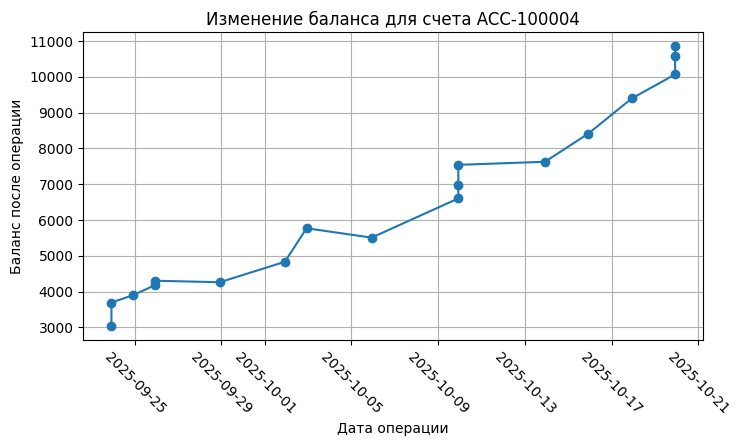

In [112]:
acc.plot_histry()